In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [39]:
import pandas as pd
import re

In [40]:
file_path = "/content/drive/MyDrive/Colab Notebooks/Data/Linux_2k.log"

# Open the raw log file and read the lines
print("\nLoading log file")
with open(file_path,"r") as file:
  raw_logs = file.readlines()

# Let's see how many logs we have and look at the first one
print(f"Total log entries successfully loaded: {len(raw_logs)}\n")
print(f"Raw log example: \n {raw_logs[0]}")


Loading log file
Total log entries successfully loaded: 2000

Raw log example: 
 Jun 14 15:16:01 combo sshd(pam_unix)[19939]: authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4 



In [41]:
log_pattern = re.compile(
    r'(\w{3}\s+\d+\s+\d{2}:\d{2}:\d{2})\s+([\w\-.]+)\s+([\w\(\)\[\]\d\-]+):\s+(.*)'
)

parsed_logs = []

for line in raw_logs:
    match = log_pattern.match(line)
    if match:
        parsed_logs.append(match.groups())

df_logs = pd.DataFrame(parsed_logs, columns=['Timestamp', 'Host', 'Component', 'Message'])

# Add year manually (since it's missing)
df_logs['Timestamp'] = pd.to_datetime(df_logs['Timestamp'] + ' 2026')

print(f"Successfully parsed {len(df_logs)} log entries.")
display(df_logs.head())

Successfully parsed 1991 log entries.


,Timestamp,Host,Component,Message
0,2026-06-14 15:16:01,combo,sshd(pam_unix)[19939],authentication failure; logname= uid=0 euid=0 ...
1,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],check pass; user unknown
2,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],authentication failure; logname= uid=0 euid=0 ...
3,2026-06-15 02:04:59,combo,sshd(pam_unix)[20882],authentication failure; logname= uid=0 euid=0 ...
4,2026-06-15 02:04:59,combo,sshd(pam_unix)[20884],authentication failure; logname= uid=0 euid=0 ...


In [42]:
df_logs["Host"].value_counts()

,count
Host,
combo,1991


In [43]:
df_logs["Message"][0]

'authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4 '

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df_logs['Message'])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

tfidf_df.head()

,00,0000,0000000000000000,00000000000a0000,00000000000f0000,0000000000100000,0000000007eae000,0000000008000000,00000000ffb00000,0000000100000000,...,wed,with,wsi,you,your,zapping,zen,zone,zonelists,zummit
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


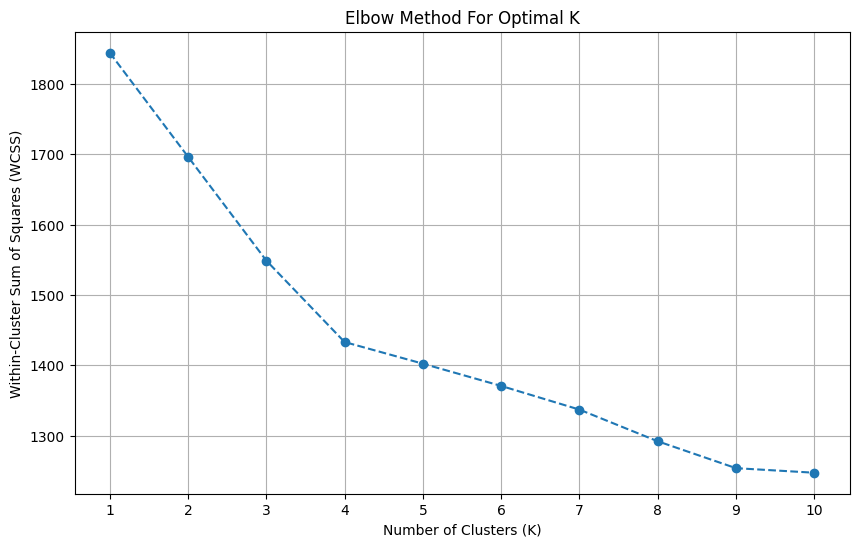

In [45]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Let's test K values from 1 to 10
K_range = range(1, 11)

for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    wcss.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [46]:
df = df_logs.copy()

In [47]:
from sklearn.cluster import KMeans

k = 4 # Based on the elbow method, assuming 4 is chosen as optimal K

# Initialize KMeans model with the chosen k
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit the model to the TF-IDF matrix and get cluster labels
df['Cluster'] = kmeans_model.fit_predict(tfidf_matrix)

print(f"K-Means clustering performed with {k} clusters.")
print("Distribution of logs per cluster:")
display(df['Cluster'].value_counts().sort_index().to_frame())

K-Means clustering performed with 4 clusters.
Distribution of logs per cluster:


,count
Cluster,
0,1138
1,490
2,117
3,246


In [48]:
df.head()

,Timestamp,Host,Component,Message,Cluster
0,2026-06-14 15:16:01,combo,sshd(pam_unix)[19939],authentication failure; logname= uid=0 euid=0 ...,1
1,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],check pass; user unknown,2
2,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],authentication failure; logname= uid=0 euid=0 ...,1
3,2026-06-15 02:04:59,combo,sshd(pam_unix)[20882],authentication failure; logname= uid=0 euid=0 ...,1
4,2026-06-15 02:04:59,combo,sshd(pam_unix)[20884],authentication failure; logname= uid=0 euid=0 ...,1


In [49]:
print("Top terms per cluster:")
order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vectorizer.get_feature_names_out()

for i in range(4):
    print(f"Cluster {i}:")
    for ind in order_centroids[i, :10]: # Print top 10 terms per cluster
        print(f' {terms[ind]}', end='')
    print('\n')

Top terms per cluster:
Cluster 0:
 at from connection 2005 jul sun 22 82 211 17

Cluster 1:
 ruser rhost euid logname tty failure nodevssh authentication uid root

Cluster 2:
 pass unknown check user 66 65536 65 63 62 61

Cluster 3:
 session for closed user opened by news cyrus test uid



In [50]:
for i in range(4):
    print(f"\n--- Sample logs from Cluster {i} ---")
    cluster_logs = df[df['Cluster'] == i]['Message'].head(5).tolist()
    for j, log in enumerate(cluster_logs):
        print(f"Log {j+1}: {log.strip()}")


--- Sample logs from Cluster 0 ---
Log 1: ALERT exited abnormally with [1]
Log 2: ALERT exited abnormally with [1]
Log 3: ALERT exited abnormally with [1]
Log 4: connection from 24.54.76.216 (24-54-76-216.bflony.adelphia.net) at Fri Jun 17 07:07:00 2005
Log 5: connection from 24.54.76.216 (24-54-76-216.bflony.adelphia.net) at Fri Jun 17 07:07:00 2005

--- Sample logs from Cluster 1 ---
Log 1: authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4
Log 2: authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=218.188.2.4
Log 3: authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=220-135-151-1.hinet-ip.hinet.net  user=root
Log 4: authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=220-135-151-1.hinet-ip.hinet.net  user=root
Log 5: authentication failure; logname= uid=0 euid=0 tty=NODEVssh ruser= rhost=220-135-151-1.hinet-ip.hinet.net  user=root

--- Sample logs from Cluster 2 ---
Log 1: check pass; user

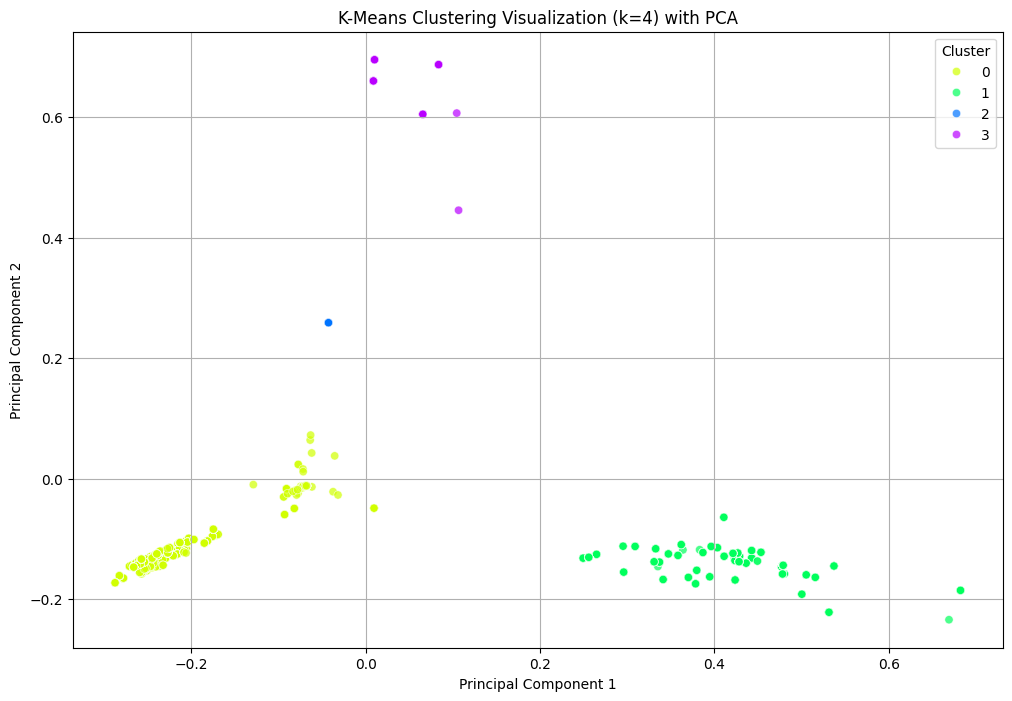

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

k = 4 # The number of clusters decided earlier

pca = PCA(n_components=2)
principal_components = pca.fit_transform(tfidf_matrix)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette=sns.color_palette('hsv', k),
    legend='full',
    alpha=0.7
)
plt.title(f'K-Means Clustering Visualization (k={k}) with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

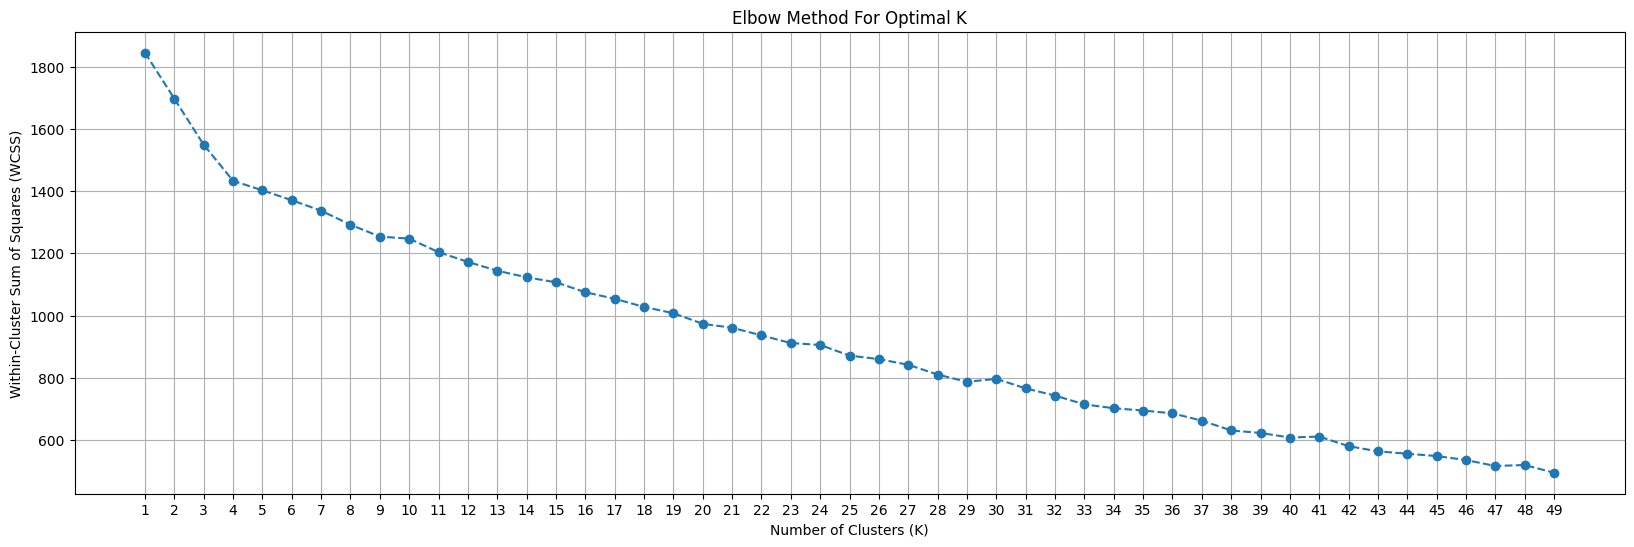

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
# Let's test K values from 1 to 10
K_range = range(1, 50)

for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    wcss.append(kmeans.inertia_)

# Plotting the elbow method
plt.figure(figsize=(20, 6))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [16]:
df.head()

,Timestamp,Host,Component,Message,Cluster
0,2026-06-14 15:16:01,combo,sshd(pam_unix)[19939],authentication failure; logname= uid=0 euid=0 ...,1
1,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],check pass; user unknown,2
2,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],authentication failure; logname= uid=0 euid=0 ...,1
3,2026-06-15 02:04:59,combo,sshd(pam_unix)[20882],authentication failure; logname= uid=0 euid=0 ...,1
4,2026-06-15 02:04:59,combo,sshd(pam_unix)[20884],authentication failure; logname= uid=0 euid=0 ...,1


In [51]:
df["Cluster_Name"] = df["Cluster"].map({
    0: "System Alerts & Connectivity",
    1: "Failed SSH Logins",
    2: "Unknown User Probes",
    3: "Active User Sessions"})

In [52]:
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day

In [53]:
df

,Timestamp,Host,Component,Message,Cluster,Cluster_Name,Year,Month,Hour,Day
0,2026-06-14 15:16:01,combo,sshd(pam_unix)[19939],authentication failure; logname= uid=0 euid=0 ...,1,Failed SSH Logins,2026,6,15,14
1,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],check pass; user unknown,2,Unknown User Probes,2026,6,15,14
2,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],authentication failure; logname= uid=0 euid=0 ...,1,Failed SSH Logins,2026,6,15,14
3,2026-06-15 02:04:59,combo,sshd(pam_unix)[20882],authentication failure; logname= uid=0 euid=0 ...,1,Failed SSH Logins,2026,6,2,15
4,2026-06-15 02:04:59,combo,sshd(pam_unix)[20884],authentication failure; logname= uid=0 euid=0 ...,1,Failed SSH Logins,2026,6,2,15
...,...,...,...,...,...,...,...,...,...,...
1986,2026-07-27 14:41:59,combo,kernel,pci_hotplug: PCI Hot Plug PCI Core version: 0.5,0,System Alerts & Connectivity,2026,7,14,27
1987,2026-07-27 14:42:00,combo,kernel,isapnp: Scanning for PnP cards...,0,System Alerts & Connectivity,2026,7,14,27
1988,2026-07-27 14:42:00,combo,kernel,isapnp: No Plug & Play device found,0,System Alerts & Connectivity,2026,7,14,27
1989,2026-07-27 14:42:00,combo,kernel,Real Time Clock Driver v1.12,0,System Alerts & Connectivity,2026,7,14,27


In [54]:
df.groupby('Month').size()

,0
Month,
6,602
7,1389


In [55]:
df.groupby(['Month', 'Message']).size().reset_index(name='Count')

,Month,Message,Count
0,6,ALERT exited abnormally with [1],16
1,6,Authentication failed from 163.27.187.39 (163....,8
2,6,Authentication failed from 163.27.187.39 (163....,15
3,6,Kerberos authentication failed,23
4,6,Received SNMP packet(s) from 67.170.148.126,1
...,...,...,...
294,7,syslogd startup succeeded,1
295,7,usbcore: registered new driver hub,1
296,7,usbcore: registered new driver usbfs,1
297,7,warning: can't get client address: Connection ...,2


In [56]:
pivot = df.pivot_table(
    index='Month',
    columns='Message',
    aggfunc='size',
    fill_value=0
)
pivot

Message,*** info [mice.c(1766)]:,0MB HIGHMEM available.,126MB LOWMEM available.,ACPI disabled because your bios is from 2000 and too old,ACPI: ACPI tables contain no PCI IRQ routing entries,ACPI: Interpreter disabled.,ACPI: Subsystem revision 20040326,ALERT exited abnormally with [1],"ANONYMOUS FTP LOGIN FROM 84.102.20.2, (anonymous)",Authentication failed from 163.27.187.39 (163.27.187.39): Permission denied in replay cache code,...,session closed for user test,session opened for user cyrus by (uid=0),session opened for user news by (uid=0),session opened for user root by LOGIN(uid=0),session opened for user test by (uid=509),syslogd startup succeeded,usbcore: registered new driver hub,usbcore: registered new driver usbfs,warning: can't get client address: Connection reset by peer,zapping low mappings.
Month,,,,,,,,,,,,,,,,,,,,,
6,0,0,0,0,0,0,0,16,0,8,...,11,16,16,0,11,0,0,0,0,0
7,1,1,1,1,1,1,1,27,2,0,...,25,27,27,1,25,1,1,1,2,1


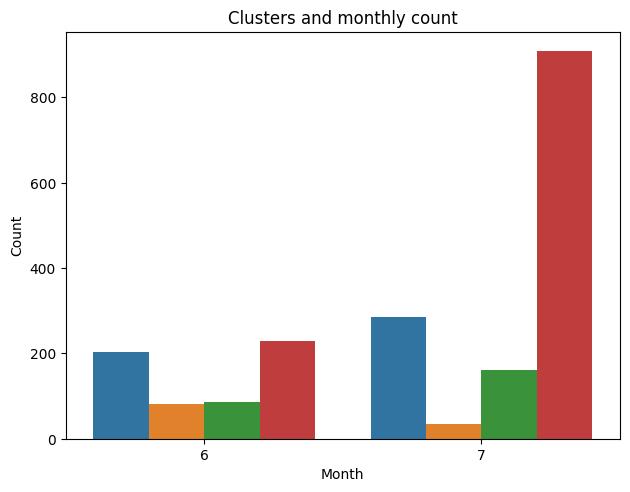

In [62]:
sns.countplot(data=df, x='Month', hue='Cluster_Name', legend = '')
plt.tight_layout()
plt.title("Clusters and monthly count")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

In [65]:
df.groupby('Hour').size()[:5]

,0
Hour,
0,10
1,60
2,58
3,112
4,290


In [67]:
df.groupby(['Month', 'Hour']).size().reset_index(name='Count')[:5]

,Month,Hour,Count
0,6,1,30
1,6,2,28
2,6,3,58
3,6,4,125
4,6,7,8


In [68]:
pivot = df.pivot_table(
    index='Month',
    columns='Hour',
    aggfunc='size',
    fill_value=0
)

pivot

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Month,,,,,,,,,,,,,,,,,,,,,
6,0,30,28,58,125,0,0,8,20,38,...,27,3,0,0,13,24,80,10,20,9
7,10,30,30,54,165,31,63,91,63,66,...,130,32,103,16,23,46,14,23,23,142


In [70]:
df.groupby(['Cluster_Name', 'Month', 'Hour']).size().reset_index(name='Count')

,Cluster_Name,Month,Hour,Count
0,Active User Sessions,6,4,64
1,Active User Sessions,6,20,2
2,Active User Sessions,6,22,20
3,Active User Sessions,7,1,16
4,Active User Sessions,7,4,108
...,...,...,...,...
83,Unknown User Probes,7,4,10
84,Unknown User Probes,7,11,1
85,Unknown User Probes,7,13,5
86,Unknown User Probes,7,14,4


<Axes: xlabel='Month_Hour', ylabel='count'>

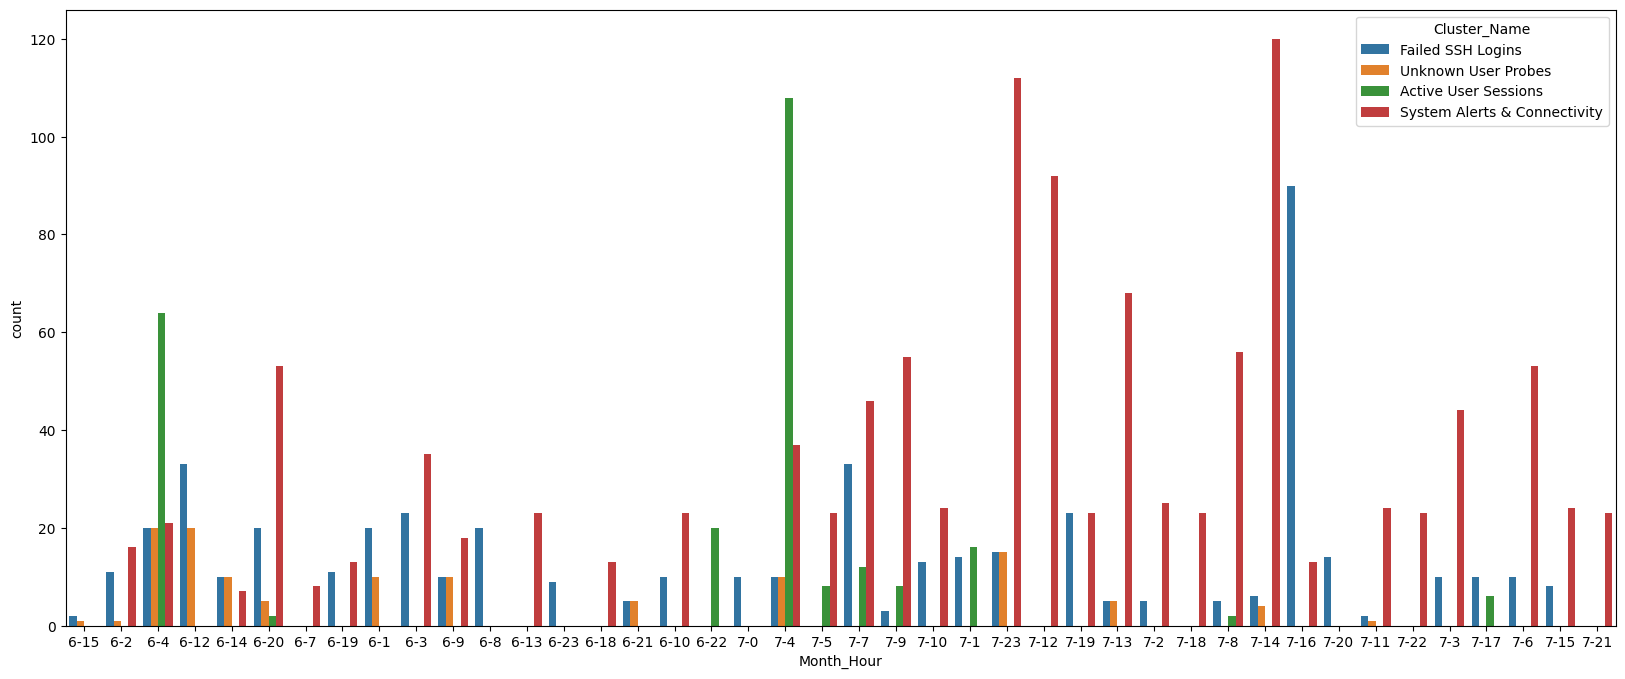

In [71]:
df['Month_Hour'] = df['Month'].astype(str) + '-' + df['Hour'].astype(str)
plt.figure(figsize=(20, 8))
sns.countplot(data=df, x='Month_Hour', hue='Cluster_Name')

In [72]:
df.head()

,Timestamp,Host,Component,Message,Cluster,Cluster_Name,Year,Month,Hour,Day,Month_Hour
0,2026-06-14 15:16:01,combo,sshd(pam_unix)[19939],authentication failure; logname= uid=0 euid=0 ...,1,Failed SSH Logins,2026,6,15,14,6-15
1,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],check pass; user unknown,2,Unknown User Probes,2026,6,15,14,6-15
2,2026-06-14 15:16:02,combo,sshd(pam_unix)[19937],authentication failure; logname= uid=0 euid=0 ...,1,Failed SSH Logins,2026,6,15,14,6-15
3,2026-06-15 02:04:59,combo,sshd(pam_unix)[20882],authentication failure; logname= uid=0 euid=0 ...,1,Failed SSH Logins,2026,6,2,15,6-2
4,2026-06-15 02:04:59,combo,sshd(pam_unix)[20884],authentication failure; logname= uid=0 euid=0 ...,1,Failed SSH Logins,2026,6,2,15,6-2


In [73]:
df["Component"].value_counts()

,count
Component,
kernel,76
logrotate,43
named[2306],16
cups,12
sshd(pam_unix)[19085],3
...,...
sshd(pam_unix)[7697],1
sshd(pam_unix)[7702],1
sshd(pam_unix)[7694],1
